Reaction Diffusion with icrn
==================

This notebook will cover how to perform spatial simulations with icrn.

In [ ]:
!pip install icrn

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from icrn import (
    MassActionReaction,
    many_index_symbols,
    many_rate_constants,
    many_species,
    solve_reaction_diffusion,
)

# Unindexed Example

We will start with the Gray-Scott system.

In [2]:
U, V = many_species("U, V")
f, k = many_rate_constants("f, k")

In [3]:
gray_scott_rxns = [
    MassActionReaction(U + 2 * V, 3 * V, 1),
    MassActionReaction(V, 0, f + k),
    MassActionReaction(0, U, f),
    MassActionReaction(U, 0, f),
]

We ask for a spatial simulation by passing the grid shape `spatial_dims` and the grid spacing `dspaces` to `solve_reaction_diffusion`. Diffusion is solved with a spectral method; here we use periodic boundary conditions. The reaction step uses the `"relu"` mode, which keeps concentrations non-negative.

In [4]:
spatial_dims = (200, 200)  # (H, W)
dspaces = (1.0, 1.0)  # grid spacing along H and W
dt = 1.0
times = jnp.array([10_000.0])

The concentration arrays live on the grid, so their leading two axes are height and width. The rate and diffusion constants are scalars shared across the grid.

In [5]:
H, W = spatial_dims

V_init = np.zeros((H, W))
V_init[H // 2 - 1 : H // 2 + 2, W // 2 - 1 : W // 2 + 2] = 1
noise = 0.18 * jax.random.uniform(jax.random.key(12), shape=(H, W))

conc_vals = {
    U: 1.0 + noise,
    V: V_init + noise,
}

rate_constant_vals = {
    f: jnp.array(0.0370),
    k: jnp.array(0.0600),
}

diffusion_constant_vals = {
    U: jnp.array(0.2),
    V: jnp.array(0.1),
}

In [6]:
print(conc_vals[U].shape)  # (H, W)
print(conc_vals[V].shape)  # (H, W)
print(rate_constant_vals[f].shape)  # scalar
print(rate_constant_vals[k].shape)  # scalar
print(diffusion_constant_vals[U].shape)  # scalar
print(diffusion_constant_vals[V].shape)  # scalar

(200, 200)
(200, 200)
()
()
()
()


In [7]:
sim_concs = solve_reaction_diffusion(
    gray_scott_rxns,
    conc_vals,
    rate_constant_vals,
    diffusion_constant_vals,
    times,
    dt,
    spatial_dims,
    dspaces,
    reaction_solver="RK4",
    boundary_condition="periodic",
    mode="relu",
)

final_concs = {s: hist[-1] for s, hist in sim_concs.items()}

Below are helper functions that convert the concentrations into values that can be plotted as an image.

In [8]:
def normalise(channel):
    lo = channel.min(axis=(0, 1))
    hi = channel.max(axis=(0, 1))
    return (channel - lo) / (hi - lo)


def state_to_image(state):
    # convert to RGB and normalise to [0, 1]
    r = normalise(state[V])
    g = normalise(state[U])
    b = 1 - (r + g) / 2
    return jnp.stack([r, g, b], axis=2)

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(state_to_image(final_concs), interpolation="none")
plt.show()

# Indexed Example

In the indexed case, the first two leading dimensions remain height and width. The dimensions that follow height and width correspond to the index set of the base object. For some base object $X$, with $\mathcal{I}(X) = J_1 \times \dots \times J_N$,

$$[X].\text{shape} = (H, W, |J_1|, \dots, |J_N|)$$

In [10]:
i = many_index_symbols("i", 3)

indexed_rxns = [
    MassActionReaction(U[i] + 2 * V[i], 3 * V[i], 1),
    MassActionReaction(V[i], 0, f[i] + k[i]),
    MassActionReaction(0, U[i], f[i]),
    MassActionReaction(U[i], 0, f[i]),
]

The leading dimensions of the base species concentrations are still height and width, now followed by the index axis of size 3. The rate and diffusion constants of the base species `U`, `V` are one-dimensional arrays of size 3. We reuse the same grid, step size, and total time as before.

In [11]:
V_init = np.zeros((H, W, 3))
V_init[H // 2 - 1 : H // 2 + 2, W // 2 - 1 : W // 2 + 2, ...] = 1
noise = 0.18 * jax.random.uniform(jax.random.key(12), shape=(H, W, 3))

conc_vals = {
    U: 1.0 + noise,
    V: V_init + noise,
}

# each (f[i], k[i]) pair corresponds to a different class of Gray-Scott pattern
rate_constant_vals = {
    f: jnp.array([0.0370, 0.0360, 0.0340]),
    k: jnp.array([0.0600, 0.0573, 0.0630]),
}

# one diffusion constant per index, so each is an array of size 3
diffusion_constant_vals = {
    U: jnp.full(3, 0.2),
    V: jnp.full(3, 0.1),
}

In [12]:
print(conc_vals[U].shape)  # (H, W, 3)
print(conc_vals[V].shape)  # (H, W, 3)
print(rate_constant_vals[f].shape)  # (3,)
print(rate_constant_vals[k].shape)  # (3,)
print(diffusion_constant_vals[U].shape)  # (3,)
print(diffusion_constant_vals[V].shape)  # (3,)

(200, 200, 3)
(200, 200, 3)
(3,)
(3,)
(3,)
(3,)


In [13]:
sim_concs = solve_reaction_diffusion(
    indexed_rxns,
    conc_vals,
    rate_constant_vals,
    diffusion_constant_vals,
    times,
    dt,
    spatial_dims,
    dspaces,
    reaction_solver="RK4",
    boundary_condition="periodic",
    mode="relu",
)

final_concs = {s: hist[-1] for s, hist in sim_concs.items()}

As expected, `U[i]` and `V[i]` have the class of Gray-Scott pattern specified by `(f[i], k[i])`.

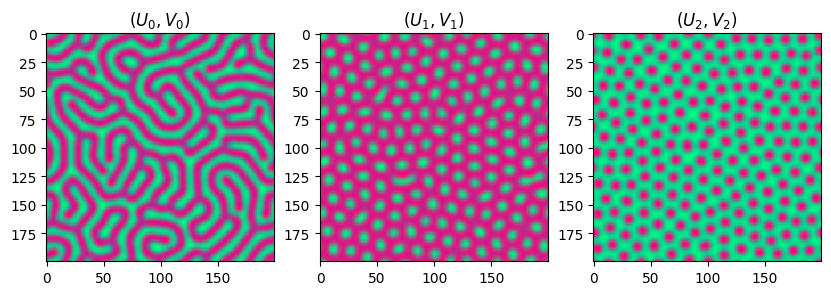

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(10, 6))
img = state_to_image(final_concs)
for idx in range(3):
    axs[idx].imshow(img[..., idx], interpolation="none")  # indexed by i
    axs[idx].set_title(f"$(U_{idx}, V_{idx})$")
plt.show()